<a href="https://colab.research.google.com/github/Priya-DharshiniRamesh/24ADI006_DEEP-LEARNING/blob/main/DL_EXP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DEEP LEARNING -24ADI006**

**EXPT NO: 4	TRANSFER LEARNING USING PRE-TRAINED VISION MODELS FOR IMAGE RECOGNITION**

**Name:Priya Dharshini R**\
**Roll no:24BAD092**

**AIM**

To implement transfer learning using pre-trained vision models for image recognition and evaluate their performance on real-world image datasets.

**SOFTWARE REQUIREMENTS**

•	Python

•	TensorFlow/Keras or PyTorch

•	Google Colab

•	Hugging Face Transformers

•	Kaggle Dataset

•	Matplotlib

•	GitHub

**OBJECTIVES**

Students will be able to:

•	Understand the concept of transfer learning.

•	Apply pre-trained vision models for image recognition.

•	Fine-tune models such as ResNet or AlexNet.

•	Utilize Kaggle datasets and Hugging Face vision models.

•	Compare transfer learning performance with custom CNN models.


In [2]:
!pip install -q kaggle

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured successfully.")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API configured successfully.


In [4]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:02<00:00, 88.8MB/s]



In [5]:
import zipfile
import os

with zipfile.ZipFile('/content/cat-and-dog.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
import os

for root, dirs, files in os.walk('/content'):
    if 'cats' in dirs and 'dogs' in dirs:
        print(root)

/content/test_set/test_set
/content/training_set/training_set


In [7]:
import os

print("Searching for dataset folders...\n")

for root, dirs, files in os.walk('/content'):
    if 'cats' in dirs or 'dogs' in dirs:
        print(root)

Searching for dataset folders...

/content/test_set/test_set
/content/training_set/training_set


**Task A: DATASET PREPARATION**

Perform the following tasks:

•	Download an image dataset from Kaggle.

•	Load and preprocess the images.

•	Split the dataset into training, validation, and testing sets.


Student Name: Priya Dharshini R
Roll No: 24BAD092
Task A: Dataset Preparation

Checking Dataset Paths
Training folder exists: True
Testing folder exists: True

Training folder contents:
['dogs', 'cats']

Testing folder contents:
['dogs', 'cats']

Loading Training Dataset:
Found 8005 files belonging to 2 classes.

Loading Test Dataset:
Found 2023 files belonging to 2 classes.

Dataset Information
Number of classes: 2
Classes: ['cats', 'dogs']
Number of training batches: 251
Number of validation batches: 32
Number of testing batches: 32


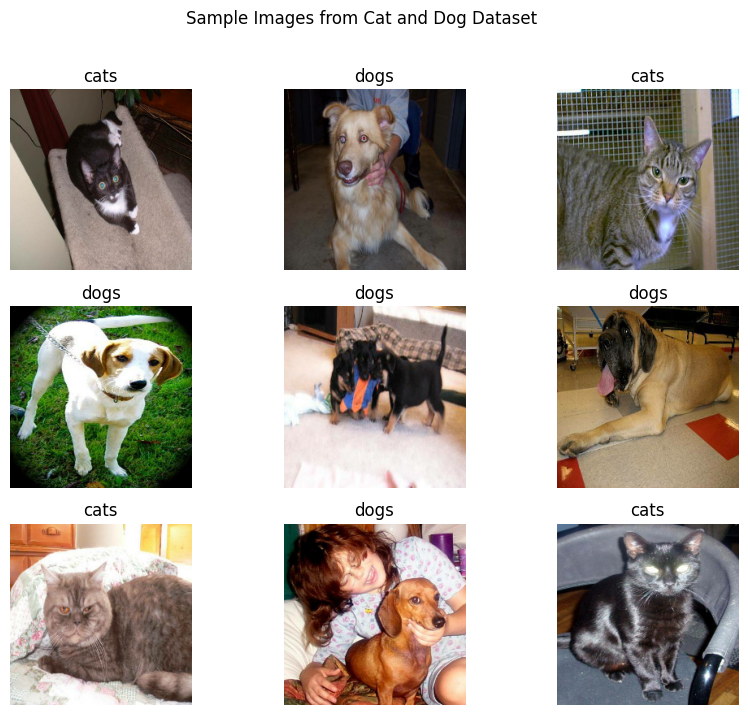


Task A completed successfully.
Student Name: Priya Dharshini R
Roll No: 24BAD092


In [8]:
# TASK A: DATASET PREPARATION

import os
import tensorflow as tf
import matplotlib.pyplot as plt

print(" Priya Dharshini R")
print("24BAD092")
print("Task A: Dataset Preparation")

# Dataset paths
train_dir = '/content/training_set/training_set'
test_dir = '/content/test_set/test_set'

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 123

print("\nChecking Dataset Paths")

print("Training folder exists:", os.path.exists(train_dir))
print("Testing folder exists:", os.path.exists(test_dir))

print("\nTraining folder contents:")
print(os.listdir(train_dir))

print("\nTesting folder contents:")
print(os.listdir(test_dir))

# Load training dataset
print("\nLoading Training Dataset:")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED
)

# Save class names before prefetching
class_names = train_dataset.class_names

# Load test dataset
print("\nLoading Test Dataset:")

test_full_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED
)

# Split test dataset into validation and testing
total_batches = tf.data.experimental.cardinality(
    test_full_dataset
).numpy()

test_dataset = test_full_dataset.take(
    total_batches // 2
)

val_dataset = test_full_dataset.skip(
    total_batches // 2
)

print("\nDataset Information")

print(
    "Number of classes:",
    len(class_names)
)

print(
    "Classes:",
    class_names
)

print(
    "Number of training batches:",
    tf.data.experimental.cardinality(
        train_dataset
    ).numpy()
)

print(
    "Number of validation batches:",
    tf.data.experimental.cardinality(
        val_dataset
    ).numpy()
)

print(
    "Number of testing batches:",
    tf.data.experimental.cardinality(
        test_dataset
    ).numpy()
)

# Optimize data loading
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

# Display sample images
plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i].numpy()]
        )

        plt.axis("off")

plt.suptitle(
    "Sample Images from Cat and Dog Dataset"
)

plt.show()

print("\nTask A completed successfully.")

**Task B: IMPLEMENTING TRANSFER LEARNING**

Load a pre-trained model such as:

•	ResNet-50

•	AlexNet

Replace the final classification layer according to the dataset classes.

Freeze the feature extraction layers.
Compile the model.


In [9]:
# TASK B: IMPLEMENTING TRANSFER LEARNING

import tensorflow as tf

print(" Priya Dharshini R")
print(" 24BAD092")
print("Task B: Implementing Transfer Learning")

print("\nLoading pre-trained ResNet-50 model...")

# ResNet-50 preprocessing
preprocess_input = tf.keras.applications.resnet50.preprocess_input

# Load ResNet-50 without the original classification layer
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

print("ResNet-50 loaded successfully.")

# Freeze the feature extraction layers
base_model.trainable = False

print("Feature extraction layers frozen.")

# Create input layer
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

# Apply ResNet-50 preprocessing
x = preprocess_input(inputs)

# Extract features using ResNet-50
x = base_model(
    x,
    training=False
)

# Convert feature maps into a feature vector
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Dropout for regularization
x = tf.keras.layers.Dropout(0.2)(x)

# Binary classification: Cat or Dog
outputs = tf.keras.layers.Dense(
    1,
    activation='sigmoid'
)(x)

# Create final model
model = tf.keras.Model(
    inputs,
    outputs
)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nResNet-50 Transfer Learning Model")
model.summary()

print("\nTotal parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(
        tf.size(variable).numpy()
        for variable in model.trainable_variables
    )
)

print("\nTask B completed successfully.")

Student Name: Priya Dharshini R
Roll No: 24BAD092
Task B: Implementing Transfer Learning

Loading pre-trained ResNet-50 model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet-50 loaded successfully.
Feature extraction layers frozen.

ResNet-50 Transfer Learning Model


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)


Total parameters: 23589761
Trainable parameters: 2049

Task B completed successfully.
Student Name: Priya Dharshini R
Roll No: 24BAD092


**Task C: MODEL TRAINING AND PERFORMANCE EVALUATION**

Train the transfer learning model.

**Record:**

•	Training accuracy

•	Validation accuracy

•	Training loss

•	Validation loss

•	Test accuracy

**Visualize:**

•	Accuracy vs Epoch

•	Loss vs Epoch


Student Name: Priya Dharshini R
Roll No: 24BAD092
Task C: Model Training and Performance Evaluation

Training the ResNet-50 Transfer Learning Model...
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1731s 7s/step - accuracy: 0.9694 - loss: 0.0847 - val_accuracy: 0.9890 - val_loss: 0.0311
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1746s 7s/step - accuracy: 0.9886 - loss: 0.0337 - val_accuracy: 0.9920 - val_loss: 0.0260
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1715s 7s/step - accuracy: 0.9905 - loss: 0.0262 - val_accuracy: 0.9890 - val_loss: 0.0362
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1722s 7s/step - accuracy: 0.9930 - loss: 0.0203 - val_accuracy: 0.9900 - val_loss: 0.0306
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1740s 7s/step - accuracy: 0.9951 - loss: 0.0156 - val_accuracy: 0.9930 - val_loss: 0.0332

Training completed successfully.

Final Training Results
Training Accuracy: 0.9951
Validation Accuracy: 0.9930
Training Loss: 0.0156
Validation Loss: 0.0332

Evaluating on Test Dataset...
32/32 ━━━━━━━━━

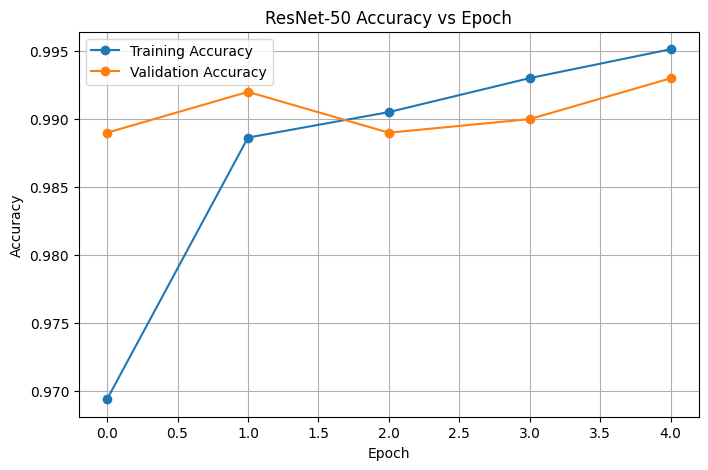

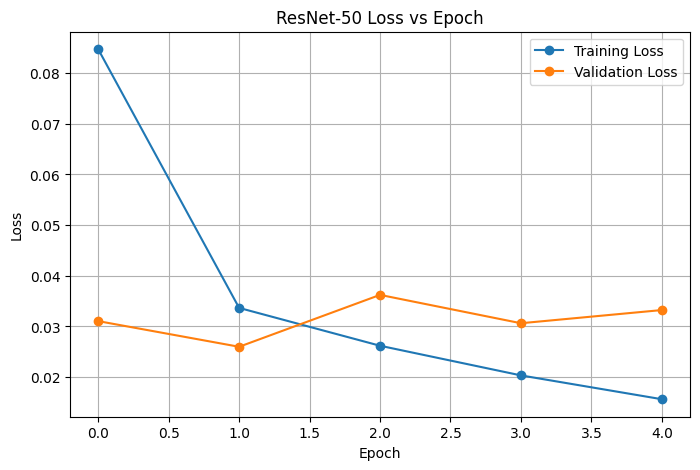


Task C completed successfully.
Student Name: Priya Dharshini R
Roll No: 24BAD092


In [10]:
# TASK C: MODEL TRAINING AND PERFORMANCE EVALUATION

import matplotlib.pyplot as plt
import tensorflow as tf

print("Priya Dharshini R")
print("24BAD092")
print("Task C: Model Training and Performance Evaluation")

print("\nTraining the ResNet-50 Transfer Learning Model...")

history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset
)

print("\nTraining completed successfully.")

# Get final training results
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\nFinal Training Results")
print(
    f"Training Accuracy: {final_train_accuracy:.4f}"
)
print(
    f"Validation Accuracy: {final_val_accuracy:.4f}"
)
print(
    f"Training Loss: {final_train_loss:.4f}"
)
print(
    f"Validation Loss: {final_val_loss:.4f}"
)

print("\nEvaluating on Test Dataset...")

test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(
    f"\nTest Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Loss: {test_loss:.4f}"
)

# Print accuracy for every epoch
print("\nAccuracy and Loss by Epoch")

for epoch in range(5):

    print(
        f"Epoch {epoch + 1}: "
        f"Training Accuracy = "
        f"{history.history['accuracy'][epoch]:.4f}, "
        f"Validation Accuracy = "
        f"{history.history['val_accuracy'][epoch]:.4f}, "
        f"Training Loss = "
        f"{history.history['loss'][epoch]:.4f}, "
        f"Validation Loss = "
        f"{history.history['val_loss'][epoch]:.4f}"
    )

# Accuracy vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy',
    marker='o'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    marker='o'
)

plt.title(
    'ResNet-50 Accuracy vs Epoch'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)
plt.show()

# Loss vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss',
    marker='o'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    marker='o'
)

plt.title(
    'ResNet-50 Loss vs Epoch'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.show()

print("\nTask C completed successfully.")

**Task D: USING HUGGING FACE PRE-TRAINED MODELS**

Perform the following tasks:

•	Load a pre-trained vision model from Hugging Face.

•	Perform image classification on sample images.

•	Compare predictions with the transfer learning model.

•	Document observations and upload the notebook to GitHub.



Student Name: Priya Dharshini R
Roll No: 24BAD092
Task D: Using Hugging Face Pre-trained Vision Model

Loading Hugging Face ViT Model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Hugging Face ViT model loaded successfully.


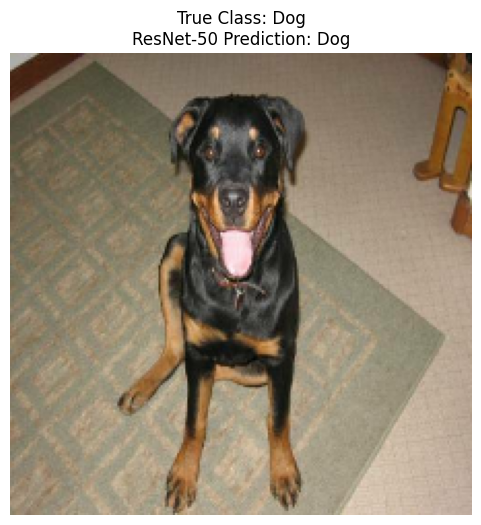


Model Predictions Comparison

1. ResNet-50 Transfer Learning Prediction: Dog
   Probability of Dog: 1.0000

2. Hugging Face ViT Top-3 Predictions:
   - Rottweiler: 0.9332
   - Doberman, Doberman pinscher: 0.0523
   - black-and-tan coonhound: 0.0065

Comparison Result
True Class: Dog
ResNet-50 Prediction: Dog
ResNet-50 correctly classified the sample image.

Observation:
The ResNet-50 model was trained specifically for Cat vs Dog binary classification, so its prediction is directly mapped to Cat or Dog.
The Hugging Face ViT model was pre-trained on ImageNet and produces more specific ImageNet labels for the input image.
Therefore, the Hugging Face ViT and ResNet-50 may produce different class names even when they identify the same type of image.
Task-specific transfer learning is useful when the required classes are different from the original ImageNet classes.

Task D completed successfully.
Student Name: Priya Dharshini R
Roll No: 24BAD092


In [12]:
# TASK D: USING HUGGING FACE PRE-TRAINED MODELS

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Priya Dharshini R")
print("24BAD092")
print("Task D: Using Hugging Face Pre-trained Vision Model")

# Install Hugging Face Transformers
!pip install -q transformers

from transformers import pipeline

# Reusing the trained ResNet-50 model and test dataset
# from Task B and Task C.
# No need to retrain ResNet-50.

print("\nLoading Hugging Face ViT Model...")

# Load pre-trained Vision Transformer from Hugging Face
hf_classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face ViT model loaded successfully.")

# Select one sample image from the existing test dataset
for images, labels in test_dataset.take(1):
    sample_image = images[0].numpy().astype("uint8")
    sample_label = labels[0].numpy()
    break

# Convert image to PIL format
pil_image = Image.fromarray(sample_image)

# Hugging Face ViT prediction
hf_predictions = hf_classifier(pil_image)

# ResNet-50 prediction using the trained model from Task C
resnet_prob = model.predict(
    np.expand_dims(sample_image, axis=0),
    verbose=0
)[0][0]

# Convert probability to class
resnet_pred_class = "Dog" if resnet_prob > 0.5 else "Cat"

# Get true class
true_class = "Dog" if sample_label == 1 else "Cat"

# Display sample image
plt.figure(figsize=(6, 6))

plt.imshow(sample_image)

plt.title(
    f"True Class: {true_class}\n"
    f"ResNet-50 Prediction: {resnet_pred_class}"
)

plt.axis("off")
plt.show()

# Print prediction comparison
print("\nModel Predictions Comparison")

print(
    f"\n1. ResNet-50 Transfer Learning Prediction: "
    f"{resnet_pred_class}"
)

print(
    f"   Probability of Dog: "
    f"{resnet_prob:.4f}"
)

print("\n2. Hugging Face ViT Top-3 Predictions:")

for pred in hf_predictions[:3]:
    print(
        f"   - {pred['label']}: "
        f"{pred['score']:.4f}"
    )

# Comparison result
print("\nComparison Result")

print(f"True Class: {true_class}")
print(f"ResNet-50 Prediction: {resnet_pred_class}")

if resnet_pred_class == true_class:
    print("ResNet-50 correctly classified the sample image.")
else:
    print("ResNet-50 incorrectly classified the sample image.")

# Observations
print("\nObservation:")

print(
    "The ResNet-50 model was trained specifically "
    "for Cat vs Dog binary classification, so its "
    "prediction is directly mapped to Cat or Dog."
)

print(
    "The Hugging Face ViT model was pre-trained on "
    "ImageNet and produces more specific ImageNet "
    "labels for the input image."
)

print(
    "Therefore, the Hugging Face ViT and ResNet-50 "
    "may produce different class names even when "
    "they identify the same type of image."
)

print(
    "Task-specific transfer learning is useful when "
    "the required classes are different from the "
    "original ImageNet classes."
)

print("\nTask D completed successfully.")